In [3]:
! pip install pandas numpy 
import numpy as np
import pandas as pd

column_names = [
    'age','sex','cp','trestbps','chol',
    'fbs','restecg','thalach','exang',
    'oldpeak','slope','ca','thal','target'
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=column_names
)

df.head()


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df['thal'].unique()

array(['6.0', '3.0', '7.0', '?'], dtype=object)

In [8]:
df.replace('?', np.nan, inplace=True)

In [9]:
df['thal'] = pd.to_numeric(df['thal'])
df['ca'] = pd.to_numeric(df['ca'])

In [10]:
df.fillna(df.median(), inplace=True)

In [11]:
df['thal'].unique()

array([6., 3., 7.])

In [12]:
df['target'].unique()

array([0, 2, 1, 3, 4])

In [13]:
df['target'] = df['target'].apply(
    lambda x: 0 if x == 0 else 1
)

In [14]:
categorical_cols = [
    'cp',
    'restecg',
    'slope',
    'thal'
]

In [15]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [16]:
df.columns


Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'ca', 'target', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0',
       'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')

In [17]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,False,False,True,False,True,True,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,False,True,False,False,False,False,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,True,False,False,False,True,False,False,False,False


In [18]:
X = df.drop('target', axis=1)

y = df['target']

In [19]:
X.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,False,False,True,False,True,True,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,False,True,False,False,False,False,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,True,False,False,False,True,False,False,False,False


In [20]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 18)
(61, 18)
(242,)
(61,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_scaled[:5]

array([[-2.83850353,  0.72250438, -0.12598175, -0.86414249, -0.39735971,
         2.31447034, -0.71589105, -0.87357299, -0.71586852,  2.1821789 ,
        -0.63794729, -0.8977584 , -0.09128709,  1.01666781, -0.91287093,
        -0.27487371, -0.25705893, -0.76948376],
       [ 0.24135234,  0.72250438,  0.97465301, -2.48363748,  2.51661148,
         1.02124161, -0.71589105, -0.70485418,  0.40181007, -0.45825757,
         1.56752763, -0.8977584 , -0.09128709, -0.98360545, -0.91287093,
        -0.27487371, -0.25705893,  1.29957258],
       [ 1.56129057,  0.72250438,  1.52497038, -0.2412598 ,  2.51661148,
        -0.85171034, -0.71589105, -0.78921359,  0.40181007, -0.45825757,
        -0.63794729, -0.8977584 , -0.09128709,  1.01666781,  1.09544512,
        -0.27487371, -0.25705893, -0.76948376],
       [ 1.12131116, -1.38407465,  1.52497038,  2.3748475 , -0.39735971,
         0.04017154, -0.71589105, -0.19869777, -0.71586852, -0.45825757,
         1.56752763, -0.8977584 , -0.09128709,  1.016

In [25]:
from xgboost import XGBClassifier

In [26]:
xgb_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
    random_state=42
)

In [27]:
xgb_model.fit(
    X_train_scaled,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_pred = xgb_model.predict(
    X_test_scaled
)

In [29]:
print(y_pred[:10])

[0 1 1 0 1 1 1 1 0 1]


In [30]:
# Correct predictions / Total predictions
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8360655737704918


In [31]:
# Among predicted disease cases, how many were actually disease?
from sklearn.metrics import precision_score
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.8928571428571429


In [32]:
# Among actual disease patients, how many did model catch?
from sklearn.metrics import recall_score
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.78125


In [33]:
y_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]
print(y_prob[:5])

[0.4075484  0.7619903  0.9923666  0.23912868 0.9623724 ]


In [34]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9137931034482759


In [35]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

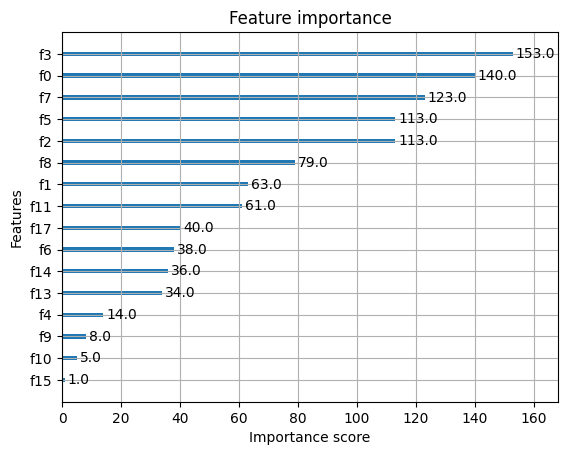

In [36]:
plot_importance(
    xgb_model
)

plt.show()

In [37]:
importance = xgb_model.feature_importances_

for feature, score in zip(
    X.columns,
    importance
):
    print(feature, score)

age 0.03944335
sex 0.05822378
trestbps 0.03963171
chol 0.038230862
fbs 0.034991045
thalach 0.031128583
exang 0.045873545
oldpeak 0.051272884
ca 0.12906657
cp_2.0 0.009837857
cp_3.0 0.028614134
cp_4.0 0.22361024
restecg_1.0 0.0
restecg_2.0 0.029149475
slope_2.0 0.09033093
slope_3.0 0.016881086
thal_6.0 0.0
thal_7.0 0.13371398


In [39]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200]
}

In [40]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [41]:
grid_search.fit(
    X_train_scaled,
    y_train
)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [42]:
print(
    grid_search.best_params_
)

print(
    grid_search.best_score_
)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
0.8855379188712522


In [44]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(
    X_test_scaled
)

In [45]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        y_pred_best
    )
)

0.8688524590163934
